In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Para que los plots se vean bien
plt.style.use("seaborn-v0_8")


In [3]:
# Cargar el CSV
df = pd.read_csv("../../../data/gold_data.csv")

# Convertir Date a datetime y ordenar
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Date,Close,High,Low,Open,Volume,VOLATILITY,ATR,DRAWDOWN,RETURN_1D,RETURN_5D,MA20,MA50,MA20/CLOSE,MA50/CLOSE,SLOPE_MA20,RSI_14,ROC_10
0,2000-11-08,265.000000,265.000000,265.000000,265.000000,0,0.007210,0.985722,-0.048132,0.002649,0.004168,267.729999,270.849998,1.010302,1.022075,-0.558991,27.433760,-0.450793
1,2000-11-09,265.799988,265.799988,265.799988,265.799988,0,0.004952,0.964292,-0.045259,0.003019,0.005295,267.199998,270.687997,1.005267,1.018390,-0.641443,25.454571,0.339749
2,2000-11-10,264.500000,264.500000,264.500000,264.500000,0,0.004059,0.942862,-0.049928,-0.004891,-0.000378,266.804999,270.411998,1.008715,1.022352,-0.701552,25.000068,0.037824
3,2000-11-13,264.299988,264.299988,264.299988,264.299988,100,0.004038,0.935719,-0.050647,-0.000756,-0.000756,266.444998,270.157997,1.008116,1.022164,-0.732089,24.561446,0.000000
4,2000-11-14,264.899994,264.899994,264.899994,264.899994,0,0.004117,0.685719,-0.048491,0.002270,0.002270,266.134998,269.939998,1.004662,1.019026,-0.697749,41.975262,0.000000


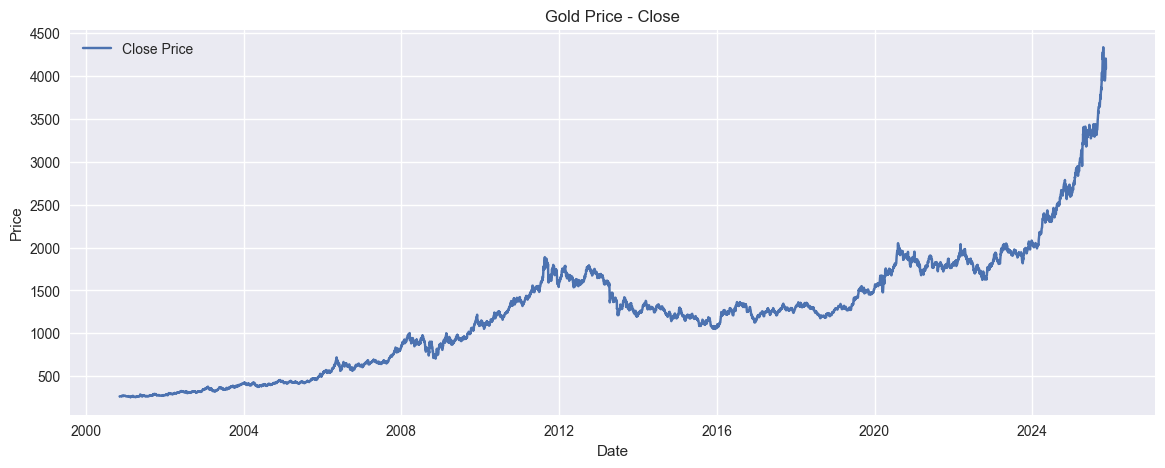

In [6]:
plt.figure(figsize=(14,5))
plt.plot(df["Date"], df["Close"], label="Close Price")

plt.title("Gold Price - Close")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year


In [8]:
start_year = df["Year"].min()
end_year = df["Year"].max()

five_year_ranges = [
    (y, y + 4) for y in range(start_year, end_year + 1, 5)
]


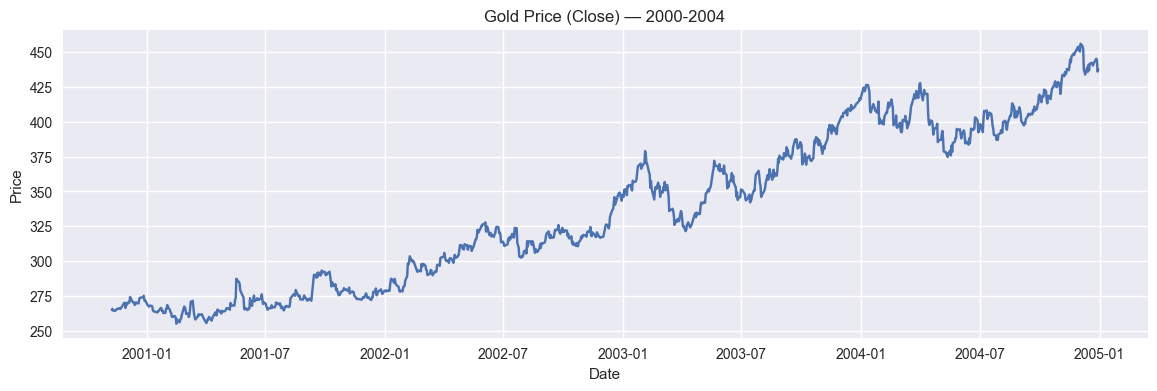

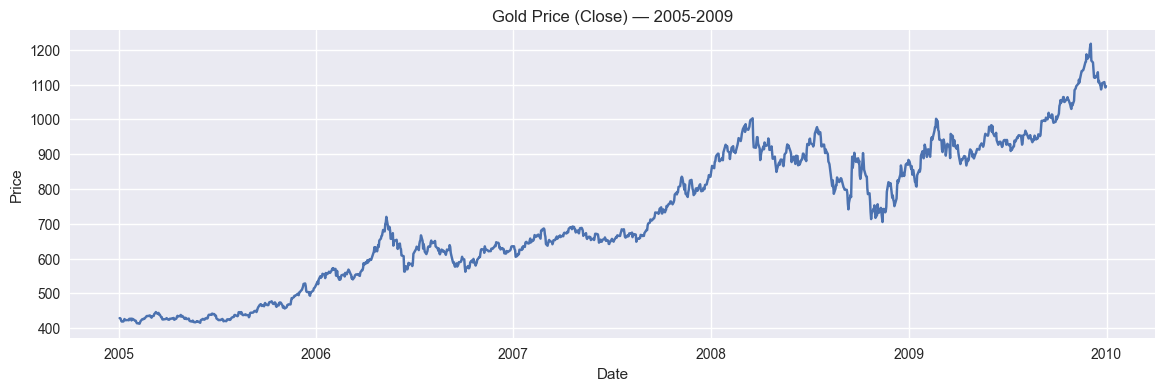

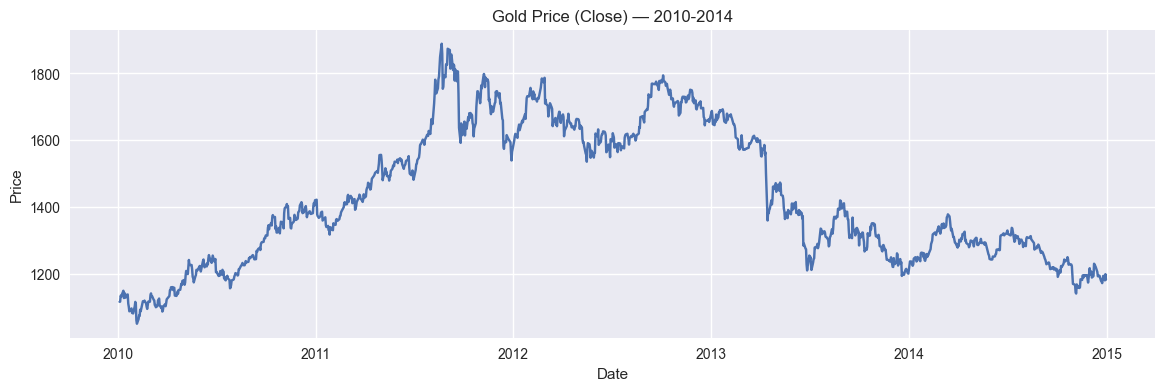

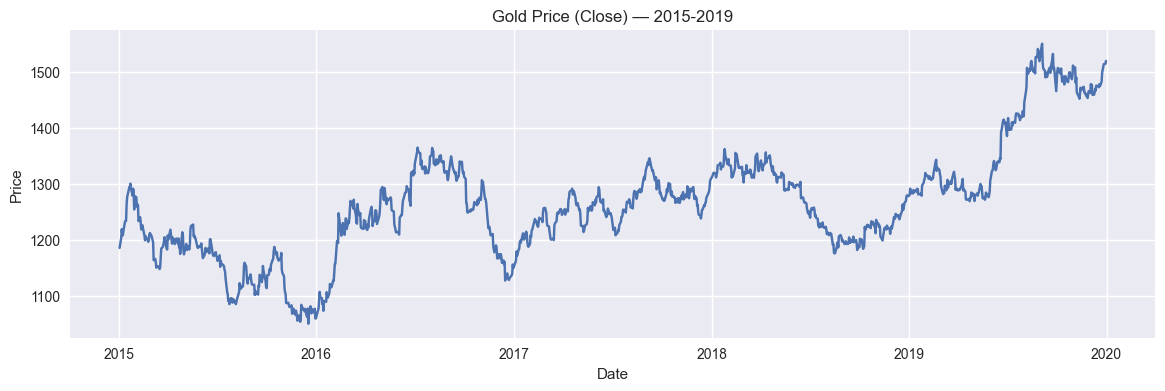

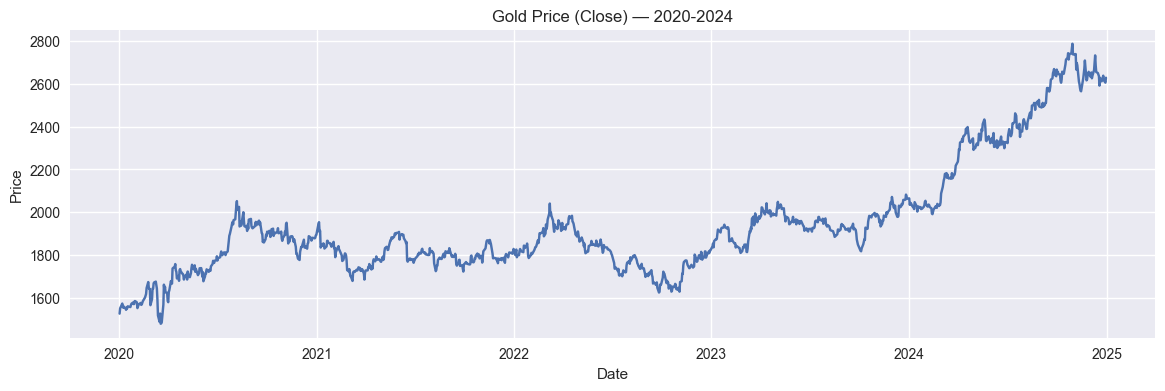

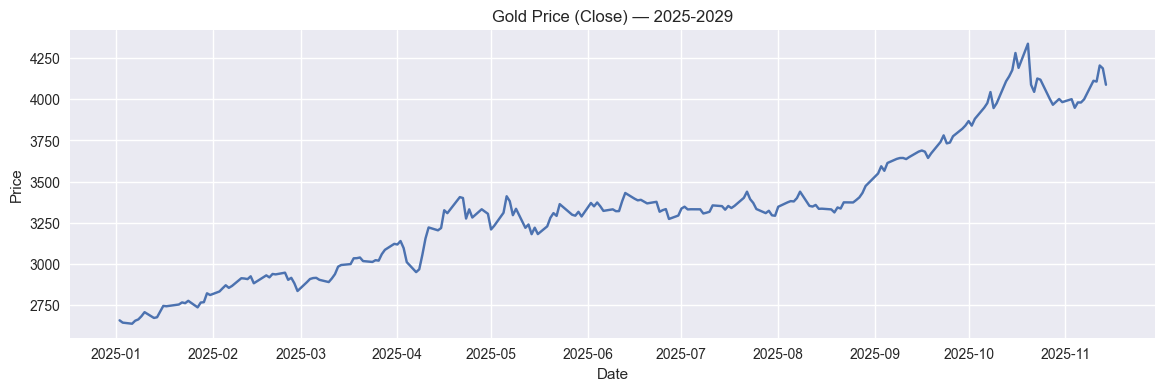

In [9]:
for start, end in five_year_ranges:
    subset = df[(df["Year"] >= start) & (df["Year"] <= end)]
    
    if subset.empty:
        continue

    plt.figure(figsize=(14,4))
    plt.plot(subset["Date"], subset["Close"])
    
    plt.title(f"Gold Price (Close) — {start}-{end}")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.grid(True)
    plt.show()


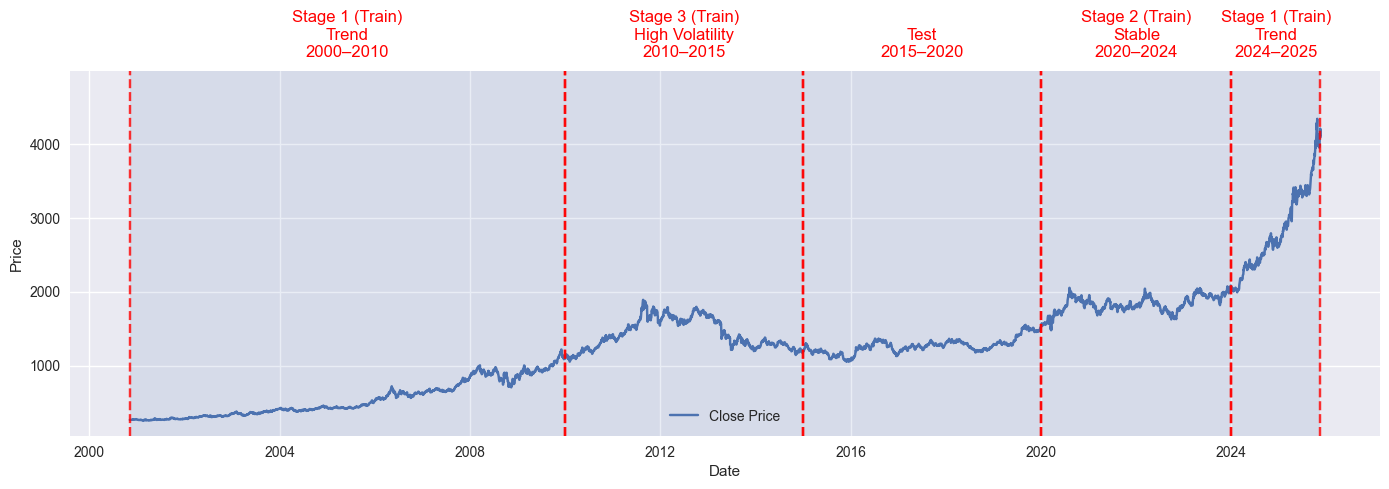

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["Date"], df["Close"], label="Close Price")

# ---- Define splits (Curriculum + Test) ----
# Trend segments (Stage 1): 2000–2010 AND 2024–end
trend_1_start = pd.Timestamp("2000-11-08")  # adjust if your dataset starts here
trend_1_end   = pd.Timestamp("2010-01-01")

trend_2_start = pd.Timestamp("2024-01-01")
trend_2_end   = df["Date"].max()  # auto: last available date in df

# High volatility (Stage 3): 2010–2015
vol_start = pd.Timestamp("2010-01-01")
vol_end   = pd.Timestamp("2015-01-01")

# Test: 2015–2020
test_start = pd.Timestamp("2015-01-01")
test_end   = pd.Timestamp("2020-01-01")

# Stable (Stage 2): 2020–2024
stable_start = pd.Timestamp("2020-01-01")
stable_end   = pd.Timestamp("2024-01-01")

# ---- Helpers ----
def add_segment(ax, start, end, label, alpha=0.12, draw_bounds=True):
    ax.axvspan(start, end, alpha=alpha)
    if draw_bounds:
        ax.axvline(start, color="red", linestyle="--", alpha=0.8)
        ax.axvline(end,   color="red", linestyle="--", alpha=0.8)
    y0, y1 = ax.get_ylim()
    y_text = y1 + (y1 - y0) * 0.03
    ax.text(start + (end - start) / 2, y_text, label, color="red",
            ha="center", va="bottom", fontsize=12)

# Make room for labels above the plot
y0, y1 = ax.get_ylim()
ax.set_ylim(y0, y1 + (y1 - y0) * 0.10)

# ---- Plot segments ----
# Stage 1: Trend (two separate windows)
add_segment(ax, trend_1_start, trend_1_end, "Stage 1 (Train)\nTrend\n2000–2010")
add_segment(ax, trend_2_start, trend_2_end, "Stage 1 (Train)\nTrend\n2024–2025")

# Stage 3: High volatility
add_segment(ax, vol_start, vol_end, "Stage 3 (Train)\nHigh Volatility\n2010–2015")

# Test
add_segment(ax, test_start, test_end, "Test\n2015–2020")

# Stage 2: Stable
add_segment(ax, stable_start, stable_end, "Stage 2 (Train)\nStable\n2020–2024")

# ---- Cosmetics ----
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()

